In [103]:
# anaconda ambiente Maq2

# Processamento de linguagem natural com Python


## Importação das bibliotecas

In [104]:
#!pip install nltk
# funções spacy e nltk processos parecidos
# spacy é mais comercial
# nltk tem mais função em inglês ao invés do português


In [105]:
#!python3 -m spacy download pt

# baixei o pacote spacy


In [106]:
#!pip install spacy


In [107]:
import bs4 as bs
import urllib.request
import nltk
import spacy

## Marcação POS

- <b>POS (part-of-speech)</b> atribui para as palavras partes da fala, como substantivos, adjetivos, verbos
- Importante para a detecção de entidades no texto, pois primeiro é necessário saber o que o texto contém
- Lista de tokens: https://spacy.io/api/annotation#pos-tagging
- Português: https://www.sketchengine.eu/portuguese-freeling-part-of-speech-tagset/

In [108]:
# download correto da biblioteca em português

In [109]:
#!python -m spacy download pt_core_news_sm


In [110]:
# ATUALIZAÇÃO DEZ-2024
# pln = spacy.load('pt')
# processamento de linguagem natural
import spacy
pln = spacy.load("pt_core_news_sm")
pln

In [111]:
# lang, de language.

In [112]:
# criar um documento, tem que colocar dentro do objeto 'pln'

documento = pln('Estou aprendendo processamento de linguagem natural, curso em Curitiba')

In [113]:
# tipo do objeto
type(documento)

spacy.tokens.doc.Doc

In [114]:
# percorrer cada uma das palavras e chamamos de token, incluindo os pontos.
# VERB - verbo
# PROPN nome próprio
# AUX auxiliar
# NOUN - nouns (substantivos) 
# ADJ adjetivo
# PUNCT pontuação

for token in documento:
  print(token.text, token.pos_)

Estou AUX
aprendendo VERB
processamento NOUN
de ADP
linguagem NOUN
natural ADJ
, PUNCT
curso NOUN
em ADP
Curitiba PROPN


## Lematização e stemização

In [115]:
for token in documento:
  print(token.text, token.lemma_)  # indicando o lema de cada uma das palavras, o radial das palavras.
# reduzir a dimensão dos dados, aprendendo para aprender, usando dentro o lemma_

Estou estar
aprendendo aprender
processamento processamento
de de
linguagem linguagem
natural natural
, ,
curso curso
em em
Curitiba Curitiba


In [116]:
doc = pln('encontrei encontraram encontrarão encontrariam cursando curso cursei')

for token in doc:
  print(token.text, token.lemma_) 

encontrei encontrar
encontraram encontrar
encontrarão encontrar
encontrariam encontrariar
cursando cursar
curso curso
cursei cursar


In [117]:
doc = pln('encontrei encontraram encontrarão encontrariam cursando curso cursei')
[token.lemma_ for token in doc]  # lemma_ coleta o radical. 

['encontrar',
 'encontrar',
 'encontrar',
 'encontrariar',
 'cursar',
 'curso',
 'cursar']

In [118]:
# para trabalhar com o chatbot

### usando a nova biblioteca e baixando o pacote
#### fazendo o stemmers

In [119]:
# usando a nova biblioteca e baixando o pacote
# fazendo o stemmers
import nltk
nltk.download('rslp')

[nltk_data] Downloading package rslp to /home/fabiene/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [120]:
# stemmer instalado e tira o radiacal da palavra em português
# sem a análise apurada do spacy
stemmer = nltk.stem.RSLPStemmer()
stemmer.stem('aprender')

'aprend'

In [121]:
for token in documento:
  print(token.text, token.lemma_, stemmer.stem(token.text))  # algumas palavras se perde o sentido (stemmer). 

Estou estar est
aprendendo aprender aprend
processamento processamento process
de de de
linguagem linguagem lingu
natural natural natur
, , ,
curso curso curs
em em em
Curitiba Curitiba curitib


In [122]:
# no dia a dia utilizamos mais a Lematização

# 25.2) Na linguagem natural vamos acessar o artigo da wikipedia para buscar os textos. 

Usaremos o link da wikipedia como referência: https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial

## 25.2.1) Carregamento dos textos

In [123]:
#<a ref-""> indica links
#Tags parágrafos, span, texto, título <h3></h3>
# tag <p> indica os textos, parágrafo. 

In [124]:
# carregar o texto:

import urllib.request

# carregar o texto:
#dados = urllib.request.urlopen('https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial')


In [125]:
import urllib.request
from bs4 import BeautifulSoup

url = 'https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial'

# adiciona um cabeçalho para simular um navegador
headers = {'User-Agent': 'Mozilla/5.0'}

# cria o objeto da requisição
req = urllib.request.Request(url, headers=headers)

# faz o download da página com o cabeçalho
with urllib.request.urlopen(req) as response:
    dados_html = response.read()

# parseia o HTML
soup = BeautifulSoup(dados_html, 'html.parser')

# extrai apenas o texto limpo da página
dados_html_final = soup.get_text()

# mostra os primeiros 1000 caracteres
print(dados_html_final[:1000])






Inteligência artificial – Wikipédia, a enciclopédia livre





























Saltar para o conteúdo







Menu principal





Menu principal
mover para a barra lateral
ocultar



		Navegação
	


Página principalConteúdo destacadoEventos atuaisEsplanadaPágina aleatóriaPortaisPáginas especiaisInformar um erro





		Colaboração
	


Boas-vindasAjudaPáginas de testes públicasPortal comunitárioMudanças recentesManutençãoCriar páginaPáginas novasContato



















Busca











Pesquisar






















Aspeto
















Doar

Criar uma conta

Entrar








Ferramentas pessoais





Doar Criar uma conta Entrar




























Conteúdo
mover para a barra lateral
ocultar




Início





1
História




Alternar a subsecção História





1.1
Investigação na IA experimental










2
Abordagens principais








3
Definição do termo








4
Campo de estudo








5
Abordagens filosóficas




Alternar a subsecção Abordagens filosóficas





5

In [126]:
print(dados_html)

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="pt" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Intelig\xc3\xaancia artificial \xe2\x80\x93 Wikip\xc3\xa9dia, a enciclop\xc3\xa9dia livre</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width

In [127]:
from IPython.display import HTML

# 1. Decodifica o conteúdo de 'dados_html' para uma string de texto.
#    Use 'utf-8', que é a codificação mais comum para HTML.
try:
    html_string = dados_html.decode('utf-8')
except AttributeError:
    # Se 'dados_html' já for uma string (str), este erro ocorre.
    # Nesse caso, apenas usa a variável original.
    html_string = dados_html

# 2. Passa a string de texto (str) para a classe HTML
display(HTML(html_string))

In [128]:
# traz todas as tags em html
dados_html = bs.BeautifulSoup(dados_html, 'lxml')
dados_html

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="pt">
<head>
<meta charset="utf-8"/>
<title>Inteligência artificial – Wikipédia, a enciclopédia livre</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-w

In [129]:
# devemos agora buscar os textos 

# tag <p> indica os textos, para fazermos a busca completa

# queremos encontrar a tag o parágrafo;

paragrafos = dados_html.find_all('p')

In [130]:
len(paragrafos)

print(f'quantidade de parágrafos no site são: {len(paragrafos)} \n')


quantidade de parágrafos no site são: 79 



In [131]:
paragrafos_0 = dados_html.find_all('<p>') # dando o valor p direito já identifica como tag <>
len(paragrafos_0)

0

In [132]:
links = dados_html.find_all('a')
print(f'quantidade de links{len(links)} \n')

links

quantidade de links1387 



[<a class="mw-jump-link" href="#bodyContent">Saltar para o conteúdo</a>,
 <a accesskey="z" href="/wiki/Wikip%C3%A9dia:P%C3%A1gina_principal" title="Visitar a página principal [z]"><span>Página principal</span></a>,
 <a href="/wiki/Portal:Conte%C3%BAdo_destacado"><span>Conteúdo destacado</span></a>,
 <a href="/wiki/Portal:Eventos_atuais" title="Informação temática sobre eventos atuais"><span>Eventos atuais</span></a>,
 <a href="/wiki/Wikip%C3%A9dia:Esplanada"><span>Esplanada</span></a>,
 <a accesskey="x" href="/wiki/Especial:Aleat%C3%B3ria" title="Carregar página aleatória [x]"><span>Página aleatória</span></a>,
 <a href="/wiki/Portal:%C3%8Dndice"><span>Portais</span></a>,
 <a href="/wiki/Especial:P%C3%A1ginas_especiais"><span>Páginas especiais</span></a>,
 <a href="/wiki/Wikip%C3%A9dia:Informe_um_erro"><span>Informar um erro</span></a>,
 <a href="/wiki/Wikip%C3%A9dia:Boas-vindas"><span>Boas-vindas</span></a>,
 <a href="/wiki/Ajuda:P%C3%A1gina_principal" title="Um local reservado para a

In [133]:
paragrafos[0]

<p>Na <a href="/wiki/Inform%C3%A1tica" title="Informática">informática</a>, a <b>Inteligência Artificial</b> (abreviado <b>IA</b>) genericamente é a <a href="/wiki/Intelig%C3%AAncia" title="Inteligência">inteligência</a>, o <a href="/wiki/Racioc%C3%ADnio_l%C3%B3gico" title="Raciocínio lógico">raciocínio</a> e o <a href="/wiki/Aprendizado_de_m%C3%A1quina" title="Aprendizado de máquina">aprendizado</a> exibida por <a href="/wiki/M%C3%A1quina" title="Máquina">máquinas</a> semelhante ao raciocino humano;<sup class="reference" id="cite_ref-:0_1-0"><a href="#cite_note-:0-1"><span class="cite-bracket">[</span>1<span class="cite-bracket">]</span></a></sup><sup class="reference" id="cite_ref-2"><a href="#cite_note-2"><span class="cite-bracket">[</span>2<span class="cite-bracket">]</span></a></sup> busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.<sup class="reference" id="cite_ref-:2_3

In [134]:
paragrafos[1]

<p>Em 1950, o matemático inglês Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano inteligente.<sup class="reference" id="cite_ref-10"><a href="#cite_note-10"><span class="cite-bracket">[</span>10<span class="cite-bracket">]</span></a></sup> Também esboçou uma proposta de pesquisa para tornar isto possível.
</p>

In [135]:
paragrafos[2]

<p><a href="/wiki/Aplicativos_de_intelig%C3%AAncia_artificial" title="Aplicativos de inteligência artificial">Aplicações de IA</a> incluem mecanismos avançados de busca na web (por exemplo, <a href="/wiki/Google_Busca" title="Google Busca">Google Search</a>); <a href="/wiki/Sistema_de_recomenda%C3%A7%C3%A3o" title="Sistema de recomendação">sistemas de recomendação</a> (usados pelo <a href="/wiki/YouTube" title="YouTube">YouTube</a>, <a href="/wiki/Amazon" title="Amazon">Amazon</a> e <a href="/wiki/Netflix" title="Netflix">Netflix</a>); <a href="/wiki/Assistente_virtual_inteligente" title="Assistente virtual inteligente">assistentes virtuais</a> (por exemplo, <a href="/wiki/Google_Assistente" title="Google Assistente">Google Assistant</a>, <a href="/wiki/Siri_(software)" title="Siri (software)">Siri</a> e <a href="/wiki/Amazon_Alexa" title="Amazon Alexa">Alexa</a> ); veículos autônomos (por exemplo, <a href="/wiki/Waymo" title="Waymo">Waymo</a>); ferramentas <a href="/wiki/Intelig%C3%AA

In [136]:
# para fazemos a aplicação do algoritmo não podemos ter tags.

In [137]:
paragrafos[1].text # texto puro do artigo

'Em 1950, o matemático inglês Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano inteligente.[10] Também esboçou uma proposta de pesquisa para tornar isto possível.\n'

In [138]:
# concatenar de forma string

In [139]:
conteudo = ''
for p in paragrafos:
  conteudo += p.text

In [140]:
print(conteudo) # conteúdo completo da página.

Na informática, a Inteligência Artificial (abreviado IA) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3][4][5][6][7] É o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1][8] É um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[9] A IA iniciou na década de 1950 com os pesquisadores Alan Turing e Herbert Simon baseado no conceito do filósofo grego Aristóteles.
Em 1950, o matemático inglês Allan Turing escreveu sobre ser possível uma máquina pensar, e imi

In [141]:
conteudo = conteudo.lower() # colocamos tudos com a letra minúscula, para utilizar no algoritmo. 
conteudo

'na informática, a inteligência artificial (abreviado ia) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3][4][5][6][7] é o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1][8] é um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[9] a ia iniciou na década de 1950 com os pesquisadores alan turing e herbert simon baseado no conceito do filósofo grego aristóteles.\nem 1950, o matemático inglês allan turing escreveu sobre ser possível uma máquina pensar, e i

# 25.3) Buscas em textos com spaCy

In [142]:
# buscar o texto com o spacy a partir da palavra chave. 

In [143]:
# ATUALIZAÇÃO DEZ-2024
# pln = spacy.load('pt')
pln = spacy.load('pt_core_news_sm')
pln

In [144]:
string = 'turing' # histórico da inteligência artificial
token_pesquisa = pln(string)

In [145]:
pln.vocab # endereço de memória, vocabulário português na memória (preposição, substantitivo, nome próprio). 

In [146]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(pln.vocab)
matcher.add('SEARCH', None, token_pesquisa) # adicionar busca, podemos colocar o nome que quiser, neste caso coloamos SEARCH.
# token de pesquisa.

In [147]:
matcher

In [148]:
conteudo[:50] # o conteúdo é o texto em forma de string

'na informática, a inteligência artificial (abrevia'

In [149]:
# vamos fazer agora a busca do texto

doc = pln(conteudo)
matches = matcher(doc)
matches

[(8661325627334373315, 130, 131),
 (8661325627334373315, 150, 151),
 (8661325627334373315, 837, 838),
 (8661325627334373315, 846, 847),
 (8661325627334373315, 883, 884),
 (8661325627334373315, 1025, 1026),
 (8661325627334373315, 4426, 4427),
 (8661325627334373315, 4436, 4437),
 (8661325627334373315, 4592, 4593),
 (8661325627334373315, 4597, 4598),
 (8661325627334373315, 4603, 4604),
 (8661325627334373315, 4666, 4667),
 (8661325627334373315, 5163, 5164),
 (8661325627334373315, 6746, 6747),
 (8661325627334373315, 6770, 6771),
 (8661325627334373315, 6879, 6880),
 (8661325627334373315, 6974, 6975),
 (8661325627334373315, 7091, 7092)]

In [150]:
len(matches) # foi encontado a palavra turing 18 vezes, 
#no primeiro tem a posição inicial e final (130, 131)

18

In [151]:
doc[130:131]

turing

In [152]:
# encontrando os indíces, segundo termo:
doc[150:151]

turing

In [153]:
# a primeira coluna é o id, há vários ids.
#8661325627334373315, 

In [154]:
#Vamos coloar os caracteres(palavras) do lado
# no exemplo abaixo são 5 palavras ou caracteres:

doc[130-5:131+5] # achando a frase de forma semi completa

1950 com os pesquisadores alan turing e herbert simon baseado no

In [155]:
doc[150-5:151+5]

, o matemático inglês allan turing escreveu sobre ser possível uma

In [156]:
# vamos retornar o matches

In [157]:
matches[0], 

((8661325627334373315, 130, 131),)

In [158]:
matches[1], 

((8661325627334373315, 150, 151),)

In [159]:
print(f'Id: {matches[0][0]}, Ponto inicial {matches[0][1]}, ponto final {matches[0][2]}')

Id: 8661325627334373315, Ponto inicial 130, ponto final 131


## mostrar o texto de uma maneira interessante

In [160]:
from IPython.core.display import HTML
texto = '' # início do texto
numero_palavras = 50 # quantidade de palavras que interessa
doc = pln(conteudo) # texto da wikipedia
matches = matcher(doc) # os resultados

# código html tag h1 para título, 
# varíavel string é a pesquisa
display(HTML(f'<h1>{string.upper()}</h1>'))
display(HTML(f"""<p><strong>Quantidade de resultados encontrados:</strong> <b>{len(matches)}</b></p>""")) # tag p é parágrafo. 
# vamos concatenar os dados
for i in matches:
  inicio = i[1] - numero_palavras # valor início - 50 palavras (coletar as palavras anteriores. 
  if inicio < 0: # verificar se pegou dados no início do texto. Não temos palavras na esquerda, comando de segurança. 
    inicio = 0
  texto += str(doc[inicio:i[2] + numero_palavras]).replace(string, f"<mark>{string}</mark>") # valor final + 50 palavras
  # += concatenar o texto
  # tag mark é para grifar na cor amarela. substituir a palavra com marca "replace(string, f"<mark>{string}</mark>")"
  texto += "<br /><br />" # vamos separar
display(HTML(f"""... {texto} ... """)) # colocar ... no início e final do texto completo.

## Teste 2 de busca

In [161]:
string = 'máquina' # histórico da inteligência artificial
token_pesquisa = pln(string)
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(pln.vocab)
matcher.add('SEARCH', None, token_pesquisa) # adicionar busca, podemos colocar o nome que quiser, neste caso coloamos SEARCH.
# token de pesquisa.

from IPython.core.display import HTML
texto = '' # início do texto
numero_palavras = 50 # quantidade de palavras que interessa
doc = pln(conteudo) # texto da wikipedia
matches = matcher(doc) # os resultados

# código html tag h1 para título, 
# varíavel string é a pesquisa
display(HTML(f'<h1>{string.upper()}</h1>'))
display(HTML(f"""<p><strong>Quantidade de resultados encontrados:</strong> <b>{len(matches)}</b></p>""")) # tag p é parágrafo. 
# vamos concatenar os dados
for i in matches:
  inicio = i[1] - numero_palavras # valor início - 50 palavras (coletar as palavras anteriores. 
  if inicio < 0: # verificar se pegou dados no início do texto. Não temos palavras na esquerda, comando de segurança. 
    inicio = 0
  texto += str(doc[inicio:i[2] + numero_palavras]).replace(string, f"<mark>{string}</mark>") # valor final + 50 palavras
  # += concatenar o texto
  # tag mark é para grifar na cor amarela. substituir a palavra com marca "replace(string, f"<mark>{string}</mark>")"
  texto += "<br /><br />" # vamos separar
display(HTML(f"""... {texto} ... """)) # colocar ... no início e final do texto completo.

## 25.4) Extração de entidades nomeadas

## Extração de entidades nomeadas

- NER (Named-Entity Recognition)
- Encontrar e classificar entidades no texto, dependendo da base de dados que foi utilizada para o treinamento (pessoa, localização, empresa, numéricos)
- Usado em chatbots para saber o assunto falado
- Siglas: https://spacy.io/api/annotation#named-entities

https://spacy.io/usage/linguistic-features#named-entities

In [162]:
for entidade in doc.ents:
  print(entidade.text, entidade.label_)

independente.[3][4][5][6][7 MISC
alan turing PER
herbert simon PER
aristóteles PER
allan turing PER
google search MISC
youtube MISC
amazon ORG
netflix PER
google assistant MISC
siri PER
waymo PER
go LOC
pessoas.[11][12 ORG
aristóteles PER
alexandre PER
allan turing PER
herbert simon PER
john mccarthy PER
turing PER
computing machinery and inteiligence MISC
turing PER
herbert simon PER
allen newell PER
turing PER
herbert simon PER
allen newell PER
the simulation of human thought MISC
brasil LOC
allen newell PER
herbert simon PER
marvin minsky PER
mit ORG
lab MISC
darthmouth LOC
defense advanced research MISC
estados unidos LOC
fifth generation MISC
” MISC
japão LOC
prolog MISC
gpt-3[29 PER
google ORG
wikipédia MISC
john mccarthy PER
andreas kaplan PER
michael haenlein PER
john mccarthy PER
román LOC
john haugeland PER
w. grey walter PER
johns hopkins PER
universidade de princeton ORG
ratio club LOC
inglaterra LOC
david rumelhart PER
ai[39 ORG
humano.[40][41 MISC
aprendem).[41 PER
google

## named entity recognition

https://spacy.io/api/entityrecognizer

Person - People, including 

NORP Nationalities or religious or political groups

FAC Buildings, airports, highways, bridges, etc

ORG Companies, agencies, institutions, etcs

GPE Countries, cities, states

LC Non-GPE locayions, mountain, ranges, bodies of water

PRODUCT Objects, vehicles, foods, etc (not. services)

EVENT Named hurricanes, battles , war, sport, events, etc

WORK_OF_ART Titles of books, songs, etc

LAW Named documents made into laws.

LANGUAGE - Any named language

DATE Absolute or relative dates or periods

TIME times smaller than a day

### SpaCy recognizes the following built-in entity types:

PERSON - People, including fictional.

NORP - Nationalities or religious or political groups.

FAC - Buildings, airports, highways, bridges, etc.

ORG - Companies, agencies, institutions, etc.

GPE - Countries, cities, states.

LOC - Non-GPE locations, mountain ranges, bodies of water.

PRODUCT - Objects, vehicles, foods, etc. (Not services.)

EVENT - Named hurricanes, battles, wars, sports events, etc.

WORK_OF_ART - Titles of books, songs, etc.

LAW - Named documents made into laws.

LANGUAGE - Any named language.

DATE - Absolute or relative dates or periods.

TIME - Times smaller than a day.

PERCENT - Percentage, including "%".

MONEY - Monetary values, including unit.

QUANTITY - Measurements, as of weight or distance.

ORDINAL - "first", "second", etc.

CARDINAL - Numerals that do not fall under another type.

### NER entity types

It allows to identify and index persons, places, organizations, etc. At the moment it can handle 6 different languages. In English, one can select among 19 kinds of entities.

CARDINAL Numerals that do not fall under another type

DATE Absolute or relative dates or periods

EVENT Named hurricanes, battles, wars, sports events, etc.
                                                    
FACILITY Buildings, airports, highways, bridges, etc.
                                                    
GPE Countries, cities, states (GeoPolitical Entity). Use our CorTexT geocoding service to locate the extracted geographical entities on the earth, and refine the coordinates (latitude and longitude) with GeoEdit Tool.

LANGUAGE Any named language

LAW Named documents made into laws

LOC (LOCATION) Non-GPE locations, mountain ranges, bodies of water

LOC_GPE combine LOC and GPE

MONEY Monetary values, including unit

NORP Nationalities or religious or political groups

ORDINAL “first”, “second”

ORG (ORGANIZATION) Companies, agencies, institutions, etc.

PERCENT Percentage (including “%”)

PERSON : People, including fictional

PRODUCT Vehicles, weapons, foods, etc. (Not services)

QUANTITY Measurements, as of weight or distance

TIME Times smaller than a day

WORK OF ART Titles of books, songs, etc.

4 kinds of entities are automatically retrieved in the 5 other languages:

LOC: countries, cities, states, mountain ranges, bodies of water (which corresponds to LOC and GPE  in English).  Use our CorTexT geocoding service to filter and locate the geographical entities on the earth, and refine the coordinates (latitude and longitude) with GeoEdit Tool.

ORG: companies, agencies, institutions, etc.

PERSON: people, including fictional.

MISC = miscellaneous entities, e. g. events, nationalities, products or works of art.

https://docs.cortext.net/named-entity-recognizer/


In [163]:
doc # -> texto

na informática, a inteligência artificial (abreviado ia) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3][4][5][6][7] é o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1][8] é um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[9] a ia iniciou na década de 1950 com os pesquisadores alan turing e herbert simon baseado no conceito do filósofo grego aristóteles.
em 1950, o matemático inglês allan turing escreveu sobre ser possível uma máquina pensar, e imi

In [164]:
for entidade in doc.ents: # ents entidade
  print(entidade.text, entidade.label_) # label (rótulo) e o texto

independente.[3][4][5][6][7 MISC
alan turing PER
herbert simon PER
aristóteles PER
allan turing PER
google search MISC
youtube MISC
amazon ORG
netflix PER
google assistant MISC
siri PER
waymo PER
go LOC
pessoas.[11][12 ORG
aristóteles PER
alexandre PER
allan turing PER
herbert simon PER
john mccarthy PER
turing PER
computing machinery and inteiligence MISC
turing PER
herbert simon PER
allen newell PER
turing PER
herbert simon PER
allen newell PER
the simulation of human thought MISC
brasil LOC
allen newell PER
herbert simon PER
marvin minsky PER
mit ORG
lab MISC
darthmouth LOC
defense advanced research MISC
estados unidos LOC
fifth generation MISC
” MISC
japão LOC
prolog MISC
gpt-3[29 PER
google ORG
wikipédia MISC
john mccarthy PER
andreas kaplan PER
michael haenlein PER
john mccarthy PER
román LOC
john haugeland PER
w. grey walter PER
johns hopkins PER
universidade de princeton ORG
ratio club LOC
inglaterra LOC
david rumelhart PER
ai[39 ORG
humano.[40][41 MISC
aprendem).[41 PER
google

In [165]:
# PER -persoa, loc, localização

In [166]:
# amazon ORGanização

In [167]:
# renderação, estilo entidade, visualização no jupyter web
# visualização mais fácil agora
from spacy import displacy
displacy.render(doc, style = 'ent', jupyter = True)

In [168]:
# MISC = miscellaneous entities, e. g. events, nationalities, products or works of art.

## 25.5) Nuvem de palavras e stop words

In [169]:
from matplotlib.colors import ListedColormap
color_map = ListedColormap(['orange', 'green', 'red', 'magenta']) # indicar as cores para mostrar as letras mais ocorridas no texto.

In [170]:
#!pip install wordcloud


In [171]:
# cor de fundo na nuvem de palavras.
# número máximo de palavras (max_words)
# colormap cores
from wordcloud import WordCloud
cloud = WordCloud(background_color = 'white', max_words = 100, colormap=color_map)

In [172]:
conteudo[:20]#texto completo do site

'na informática, a in'

In [173]:
# usando o conteúdo vem mais as palavras que são preposição. 

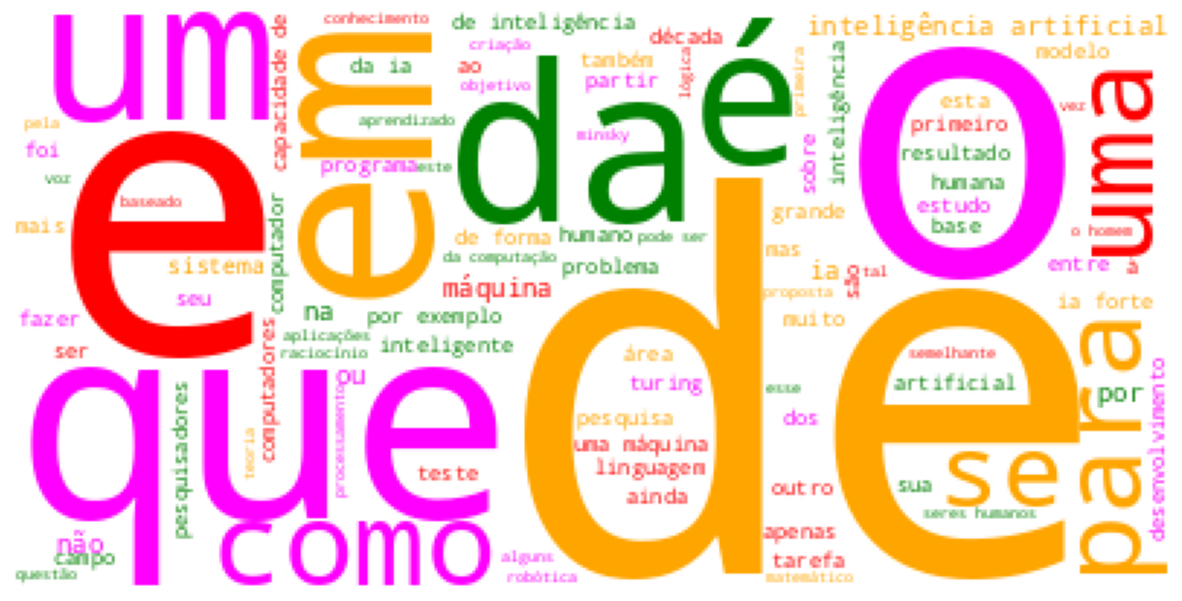

In [174]:
import matplotlib.pyplot as plt
# vamos gerar a nuvem de palavras => generate
cloud = cloud.generate(conteudo)
plt.figure(figsize=(15,15)) # tamanho da figura ou visualização. 
plt.imshow(cloud)
plt.axis('off')
plt.show()

# nuvens de palavras para ver a mais frequente, temos que ver a visualização mais adequadas. 


### Vamos remover a stop word (preposição)

In [175]:
from spacy.lang.pt.stop_words import STOP_WORDS
print(STOP_WORDS) # lista da stop words, que será retirada. 

{'disso', 'ele', 'fazia', 'da', 'for', 'em', 'cada', 'podia', 'fazeis', 'usar', 'máximo', 'têm', 'fazem', 'sei', 'tendes', 'nem', 'bastante', 'tarde', 'possivelmente', 'maioria', 'mas', 'fostes', 'sobre', 'sua', 'devem', 'tentaram', 'sexta', 'inclusive', 'cujo', 'dar', 'oito', 'ou', 'quando', 'tens', 'vens', 'tudo', 'próximo', 'somos', 'esses', 'só', 'estava', 'esteve', 'terceira', 'o', 'meio', 'nas', 'grande', 'se', 'partir', 'inicio', 'estes', 'primeiro', 'cima', 'já', 'vossos', 'tentei', 'tal', 'grandes', 'fazemos', 'mal', 'este', 'algo', 'ambas', 'sim', 'ter', 'ainda', 'novos', 'contudo', 'dezoito', 'acerca', 'desse', 'vossas', 'obrigado', 'tenho', 'apoio', 'as', 'treze', 'porquanto', 'momento', 'também', 'aquele', 'foste', 'debaixo', 'nunca', 'lugar', 'pôde', 'neste', 'nove', 'bem', 'poderá', 'adeus', 'lá', 'temos', 'dá', 'sob', 'outros', 'aos', 'sete', 'oitavo', 'lado', 'meus', 'quanto', 'próxima', 'certeza', 'coisa', 'mês', 'atrás', 'podem', 'esta', 'nosso', 'tivestes', 'ver', '

In [176]:
print(f'a quantidade da lista quer será parada ou retirada para a analise, no stopwords, que será retirada. A quantidade total de palavras retiradas é de {len(STOP_WORDS)}. ')

a quantidade da lista quer será parada ou retirada para a analise, no stopwords, que será retirada. A quantidade total de palavras retiradas é de 416. 


In [177]:
# perguntar se a palavra será parada ou não
pln.vocab['caminhar'].is_stop # não é uma stopword

False

In [178]:
# perguntar se a palavra será parada ou não
pln.vocab['usa'].is_stop # é uma stopword, será excluido, e está em string

True

In [179]:
# colocaremos no formato spacy. 
doc = pln(conteudo) # vamos gerar a lista de token
lista_token = []
for token in doc:
  lista_token.append(token.text)

In [180]:
print(lista_token) # cada um do token é colocado no formato do spacy.
# com palavras separadas na lista
# verificaremos se é uma substântivo, adjetivo, verbo. 

['na', 'informática', ',', 'a', 'inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'é', 'a', 'inteligência', ',', 'o', 'raciocínio', 'e', 'o', 'aprendizado', 'exibida', 'por', 'máquinas', 'semelhante', 'ao', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'ou', 'sistemas', 'especialistas', 'capazes', 'de', 'simular', 'o', 'pensamento', 'humano', 'e', 'realizar', 'várias', 'tarefas', 'complexas', 'de', 'forma', 'independente.[3][4][5][6][7', ']', 'é', 'o', 'sistema', 'que', 'permite', 'aos', 'computadores', 'executar', 'funções', 'avançadas', ',', 'como', 'a', 'capacidade', 'de', 'analisar', 'dados', 'em', 'grande', 'escala', 'e', 'fazer', 'previsões', '/', 'recomendações;[1][8', ']', 'é', 'um', 'campo', 'de', 'pesquisa', 'em', 'ciência', 'da', 'computação', 'que', 'desenvolve', 'e', 'estuda', 'métodos', 'e', 'softwares', 'que', 'permitem', 'que', 'as', 'máquinas', 'percebam', 'seu', 'ambiente', 'e', 'usem', 'o', 'aprendizado',

In [181]:
# criaremos uma nova lista
sem_stop = []
for palavra in lista_token:
  if pln.vocab[palavra].is_stop == False:
    sem_stop.append(palavra) # se não é uma stopword entra na lista de análise. 
    

In [182]:
print(sem_stop)

['informática', ',', 'inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'inteligência', ',', 'raciocínio', 'aprendizado', 'exibida', 'máquinas', 'semelhante', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'sistemas', 'especialistas', 'capazes', 'simular', 'pensamento', 'humano', 'realizar', 'várias', 'tarefas', 'complexas', 'independente.[3][4][5][6][7', ']', 'permite', 'computadores', 'executar', 'funções', 'avançadas', ',', 'capacidade', 'analisar', 'dados', 'escala', 'previsões', '/', 'recomendações;[1][8', ']', 'campo', 'pesquisa', 'ciência', 'computação', 'desenvolve', 'estuda', 'métodos', 'softwares', 'permitem', 'máquinas', 'percebam', 'ambiente', 'usem', 'aprendizado', 'inteligência', 'tomar', 'ações', 'maximizem', 'chances', 'atingir', 'objetivos', 'definidos.[9', ']', 'ia', 'iniciou', 'década', '1950', 'pesquisadores', 'alan', 'turing', 'herbert', 'simon', 'baseado', 'conceito', 'filósofo', 'grego', 'aristóteles', 

In [183]:
print(f'tamanho da lista do token {len(lista_token)};\ne o tamanho da lista tratada {len(sem_stop)} (sem dados do stop).')

tamanho da lista do token 7487;
e o tamanho da lista tratada 4390 (sem dados do stop).


In [184]:
# é uma lista o sem_stop, mas temos que voltar a colocar o string.

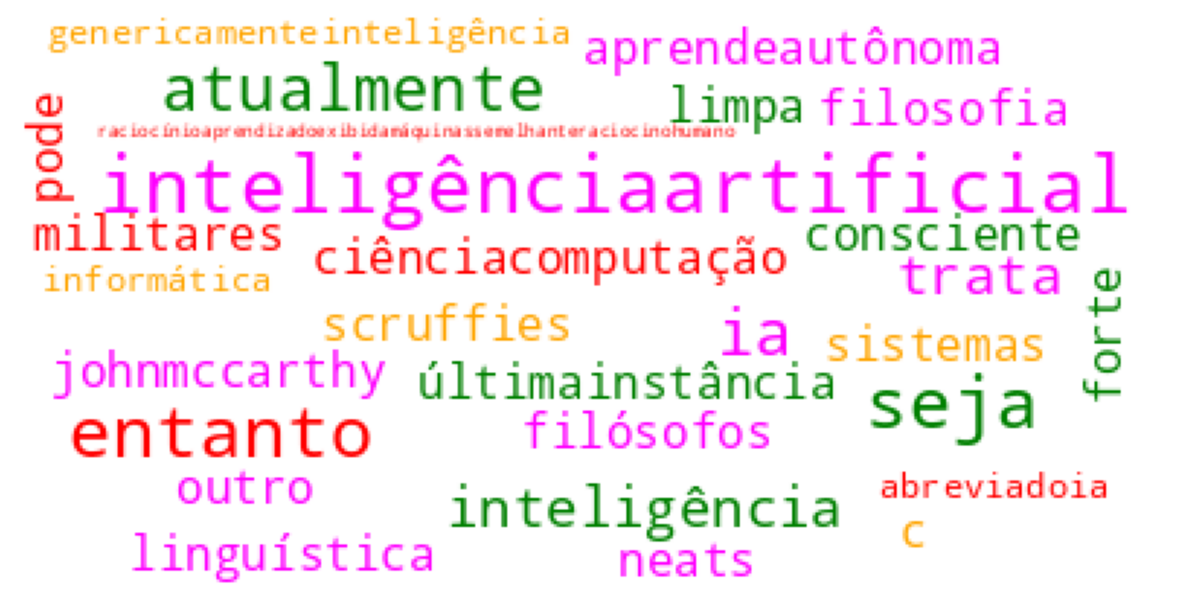

In [185]:
import matplotlib.pyplot as plt
# vamos gerar a nuvem de palavras => generate
cloud = cloud.generate(''.join(sem_stop)) # converter a lista para o string, join para juntar o element da lista 
plt.figure(figsize=(15,15)) # tamanho da figura ou visualização. 
plt.imshow(cloud)
plt.axis('off')
plt.show()

In [187]:
# nuvem de palavra. 

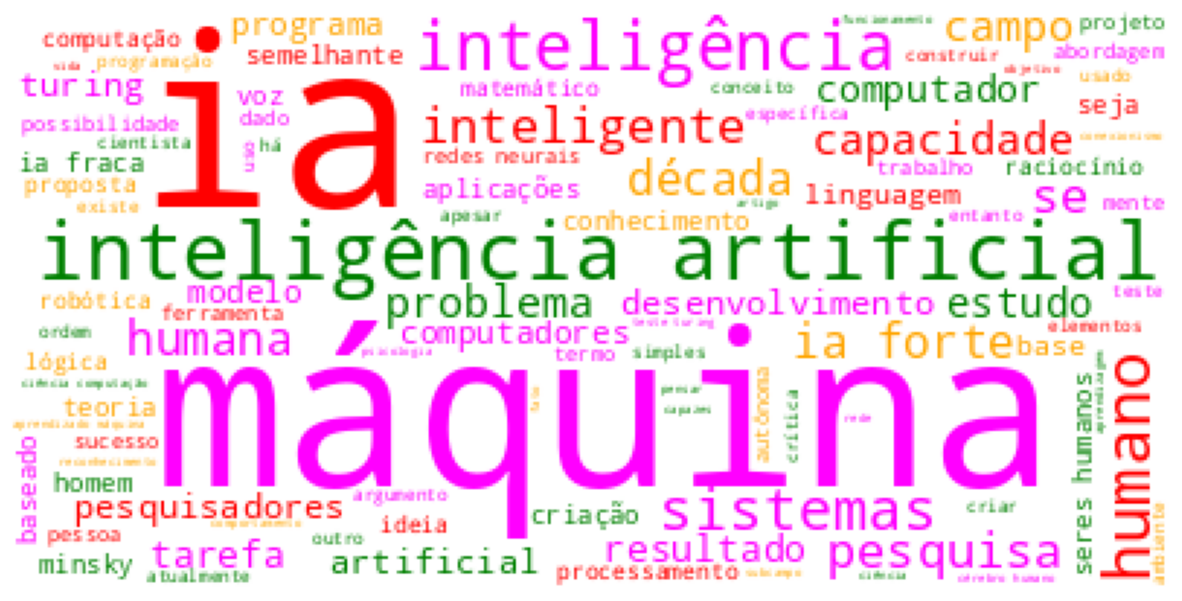

In [186]:
import matplotlib.pyplot as plt
cloud = cloud.generate(' '.join(sem_stop)) # separar de forma correta o espaço.
plt.figure(figsize=(15,15))
plt.imshow(cloud)
plt.axis('off')
plt.show()